In [50]:
!python -m pip install --upgrade pip

In [51]:
! pip install pandas

In [52]:
! pip install matplotlib

In [53]:
! pip install seaborn

In [54]:
! pip install scikit-learn

In [55]:
import pandas as pd                       
import matplotlib.pyplot as plt           
import seaborn as sns                        
from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1. LOADING DATASET

In [56]:
df = pd.read_csv(r"C:\Users\Saran\OneDrive\Desktop\heart.csv.csv")
print(f'Rows    : {df.shape[0]}  (each row = one patient)')
print(f'Columns : {df.shape[1]}  (each column = one detail about the patient)')
print()
df.head()

Rows    : 303  (each row = one patient)
Columns : 14  (each column = one detail about the patient)



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [57]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [58]:
print(df['target'].value_counts())
print()

target
1    165
0    138
Name: count, dtype: int64



### 2. EDA

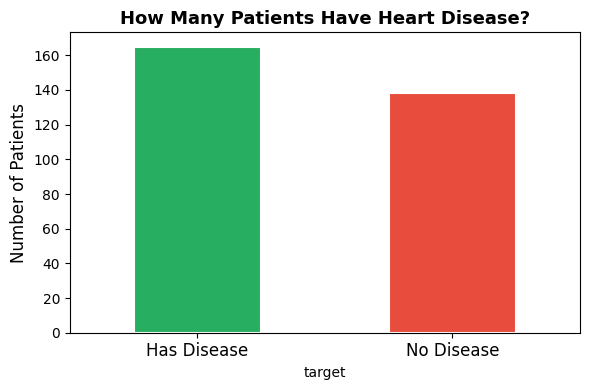

In [59]:
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['#27ae60', '#e74c3c'], 
                                  edgecolor='white', linewidth=1.5)
plt.xticks([0, 1], ['Has Disease', 'No Disease'], rotation=0, fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.title('How Many Patients Have Heart Disease?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

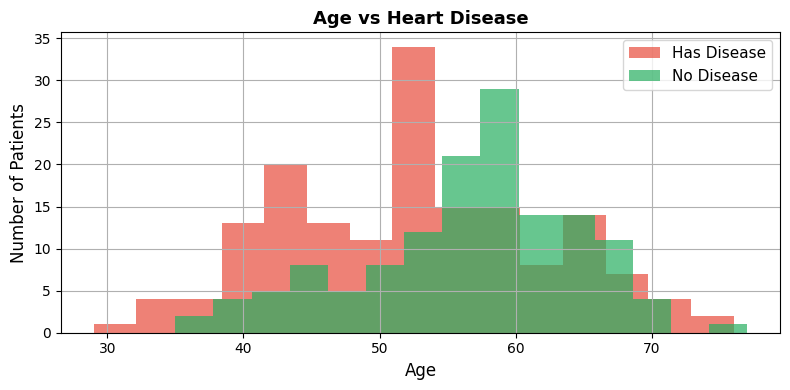

Average age with disease    : 52.5 years
Average age without disease : 56.6 years


In [60]:
plt.figure(figsize=(8, 4))
df[df['target']==1]['age'].hist(bins=15, alpha=0.7, color='#e74c3c', label='Has Disease')
df[df['target']==0]['age'].hist(bins=15, alpha=0.7, color='#27ae60', label='No Disease')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.title('Age vs Heart Disease', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Average age with disease    : {df[df['target']==1]['age'].mean():.1f} years")
print(f"Average age without disease : {df[df['target']==0]['age'].mean():.1f} years")

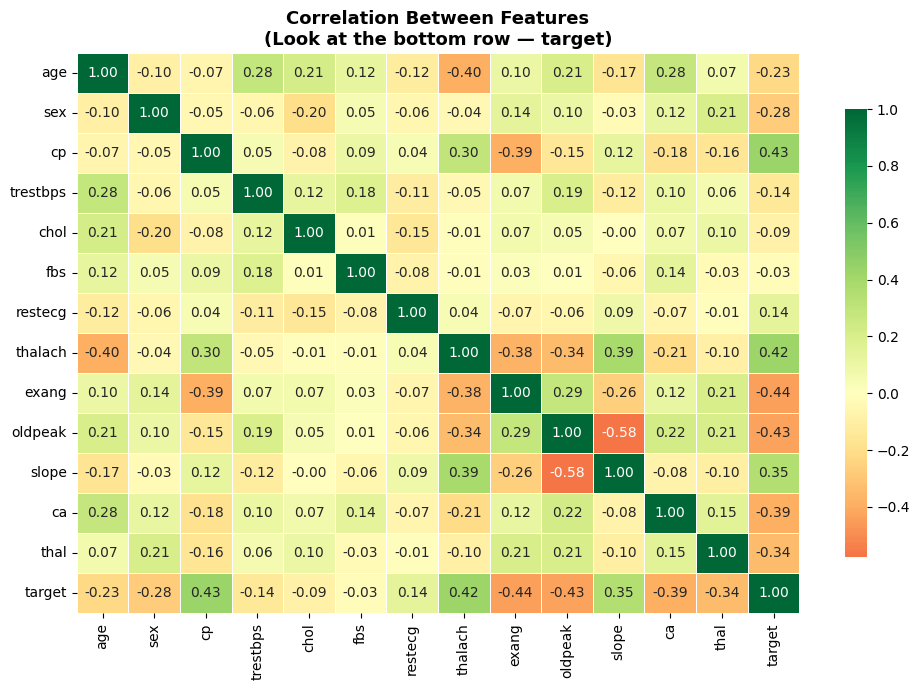

In [61]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Between Features\n(Look at the bottom row — target)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. TRAIN AND TEST THE MODEL

In [62]:
X = df.drop('target', axis=1)  
y = df['target']                 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]}')
print(f'Testing set  : {X_test.shape[0]}')
print()

Training set : 242
Testing set  : 61



In [63]:
model = LogisticRegression(max_iter=2000)


In [64]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [65]:
y_pred = model.predict(X_test)

In [66]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f'🎯 Model Accuracy: {accuracy:.1f}%')
print()
print(f'   Out of {len(y_test)} patients tested,')
print(f'   the model correctly predicted {int(accuracy/100 * len(y_test)):.0f} patients.')

🎯 Model Accuracy: 88.5%

   Out of 61 patients tested,
   the model correctly predicted 54 patients.


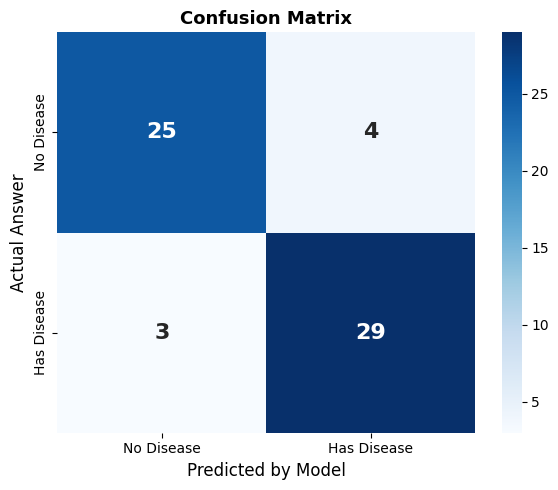

✅ Correctly predicted : 54 patients
❌ Wrong predictions   : 7 patients


In [67]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'],
            annot_kws={'size': 16, 'weight': 'bold'})
plt.xlabel('Predicted by Model', fontsize=12)
plt.ylabel('Actual Answer', fontsize=12)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✅ Correctly predicted : {cm[0][0] + cm[1][1]} patients')
print(f'❌ Wrong predictions   : {cm[0][1] + cm[1][0]} patients')

In [68]:
print('Full Classification Report:')
print('─' * 45)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Has Disease']))
print('─' * 45)
print()
print('Precision → Of all predicted Disease, how many truly had it?')
print('Recall    → Of all actual Disease cases, how many did we catch?')
print('F1-Score  → Overall balance score (closer to 1.0 = better)')

Full Classification Report:
─────────────────────────────────────────────
              precision    recall  f1-score   support

  No Disease       0.89      0.86      0.88        29
 Has Disease       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

─────────────────────────────────────────────

Precision → Of all predicted Disease, how many truly had it?
Recall    → Of all actual Disease cases, how many did we catch?
F1-Score  → Overall balance score (closer to 1.0 = better)


In [69]:
print('=' * 50)
print('   ❤️  HEART DISEASE PREDICTION — SUMMARY')
print('=' * 50)
print()
print('Dataset    : 303 patients, 13 features')
print('Model      : Logistic Regression')
print(f'Accuracy   : {accuracy:.1f}%')
print('Missing    : None — data was clean')
print()
print('Key Findings:')
print('  • 54.5% of patients had heart disease')
print('  • Most cases found in the 40–65 age group')
print('  • Chest pain type is a strong predictor')
print('  • Higher max heart rate linked to disease')
print()
print('Conclusion:')
print('  Logistic Regression predicted heart disease')
print(f'  with {accuracy:.1f}% accuracy on unseen data.')
print('=' * 50)

   ❤️  HEART DISEASE PREDICTION — SUMMARY

Dataset    : 303 patients, 13 features
Model      : Logistic Regression
Accuracy   : 88.5%
Missing    : None — data was clean

Key Findings:
  • 54.5% of patients had heart disease
  • Most cases found in the 40–65 age group
  • Chest pain type is a strong predictor
  • Higher max heart rate linked to disease

Conclusion:
  Logistic Regression predicted heart disease
  with 88.5% accuracy on unseen data.


In [71]:
! pip install streamlit
"streamlit hello"

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.2 MB 1.7 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.2 MB 2.0 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.2 MB 2.0 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/9.2 MB 2.1 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/9.2 MB 2.1 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.2 MB 2.2 MB/s eta 0:00:03
   ----------------- ---------------------- 3.9/9.2 MB 2.3 MB/s eta 0:00:03
   ------------------- -------------------- 4.5/9.2 MB 2.4 MB/s eta 0:00:03
   ----------------------- ---------------- 5.5/9.2 MB 2.6 MB/s eta 0:00:02
   --------------------------- ------------ 6.3/9.2 MB 2.8 MB/s eta 0:00:02
   ------------------------------- -------- 7.3/9.2 MB 2.9 MB/s eta 0:00:01
   -----------------------

'streamlit hello'